Download Dataset

In [4]:
from google.colab import files
import zipfile
import os

# This will prompt a file picker — select your dataset zip file
uploaded = files.upload()

# Get the uploaded file name automatically
zip_filename = list(uploaded.keys())[0]

# Unzip it
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted to /content/dataset")

# Quick peek at what got extracted
for root, dirs, files_ in os.walk('/content/dataset'):
    print(root, "->", dirs[:5], "|", len(files_), "files")
    if root.count(os.sep) > 3:
        break

Saving archive (7).zip to archive (7).zip
Dataset extracted to /content/dataset
/content/dataset -> ['PetImages'] | 0 files
/content/dataset/PetImages -> ['Cat', 'Dog'] | 0 files
/content/dataset/PetImages/Cat -> [] | 12499 files


Imports

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Data Understanding

In [7]:
 base_dir = "/content/dataset"

# Display folder structure
for root, dirs, files_ in os.walk(base_dir):
    level = root.replace(base_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files_[:3]:
            print(f"{indent}  {f}")

# Locate the folder that directly contains the two class folders
# (handles Cat/Dog, cats/dogs, Cats/Dogs, etc.)
train_dir = None
cat_folder_name = None
dog_folder_name = None

for root, dirs, files_ in os.walk(base_dir):
    lower_dirs = {d.lower(): d for d in dirs}
    if 'cat' in lower_dirs and 'dog' in lower_dirs:
        train_dir = root
        cat_folder_name = lower_dirs['cat']
        dog_folder_name = lower_dirs['dog']
        break
    elif 'cats' in lower_dirs and 'dogs' in lower_dirs:
        train_dir = root
        cat_folder_name = lower_dirs['cats']
        dog_folder_name = lower_dirs['dogs']
        break

print("\nTrain directory found at:", train_dir)
print("Cat folder:", cat_folder_name, "| Dog folder:", dog_folder_name)

cats_dir = os.path.join(train_dir, cat_folder_name)
dogs_dir = os.path.join(train_dir, dog_folder_name)

cat_files = os.listdir(cats_dir)
dog_files = os.listdir(dogs_dir)

print("Number of classes: 2 (Cats, Dogs)")
print("Total cat images:", len(cat_files))
print("Total dog images:", len(dog_files))
print("Total images:", len(cat_files) + len(dog_files))

dataset/
  PetImages/
    Cat/
    Dog/

Train directory found at: /content/dataset/PetImages
Cat folder: Cat | Dog folder: Dog
Number of classes: 2 (Cats, Dogs)
Total cat images: 12499
Total dog images: 12499
Total images: 24998


Sample Images & Dimensions

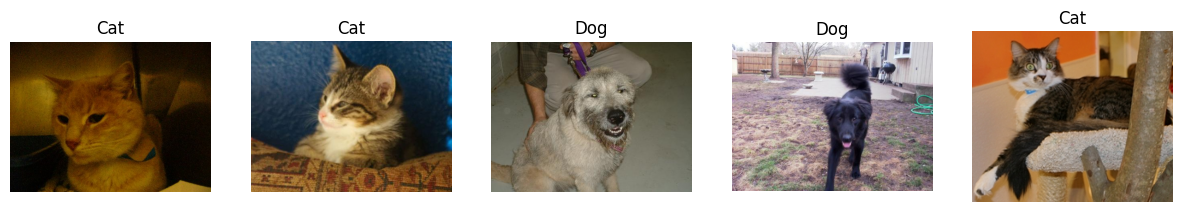

Sample image dimensions: (300, 400, 3)


In [8]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

sample_paths = [
    (os.path.join(cats_dir, cat_files[0]), "Cat"),
    (os.path.join(cats_dir, cat_files[1]), "Cat"),
    (os.path.join(dogs_dir, dog_files[0]), "Dog"),
    (os.path.join(dogs_dir, dog_files[1]), "Dog"),
    (os.path.join(cats_dir, cat_files[2]), "Cat"),
]

plt.figure(figsize=(15, 4))
for i, (path, label) in enumerate(sample_paths):
    img = load_img(path)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
plt.show()

# Check image dimensions of a sample
sample_img = load_img(sample_paths[0][0])
print("Sample image dimensions:", img_to_array(sample_img).shape)

Preprocessing & Data Generators

In [9]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,        # normalize 0-1
    validation_split=0.2   # 80/20 split
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

test_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Testing samples:", test_generator.samples)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}
Training samples: 20000
Testing samples: 4998


Build CNN Model

In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [11]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
 70/625 ━━━━━━━━━━━━━━━━━━━━ 8:44 946ms/step - accuracy: 0.5243 - loss: 0.7147

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 651s 1s/step - accuracy: 0.6780 - loss: 0.5883 - val_accuracy: 0.7365 - val_loss: 0.5267
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - accuracy: 0.7907 - loss: 0.4509 - val_accuracy: 0.7975 - val_loss: 0.4244
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 665s 1s/step - accuracy: 0.8280 - loss: 0.3790 - val_accuracy: 0.8003 - val_loss: 0.4289
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.8619 - loss: 0.3112 - val_accuracy: 0.8315 - val_loss: 0.3710
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 624s 998ms/step - accuracy: 0.9048 - loss: 0.2274 - val_accuracy: 0.8399 - val_loss: 0.4180
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 627s 1s/step - accuracy: 0.9395 - loss: 0.1527 - val_accuracy: 0.8263 - val_loss: 0.4710
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.9646 - loss: 0.0919 - val_accuracy: 0.8347 - val_loss: 0.5527
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 680s 1000ms/step - accuracy: 0.9765 - loss: 0.0636 - val_accuracy

Evaluation Metrics

In [12]:
# Test accuracy
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 287ms/step - accuracy: 0.8329 - loss: 0.7731
Test Accuracy: 0.8329
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 279ms/step
Precision: 0.8559
Recall: 0.8007
F1-Score: 0.8274


Confusion Matrix

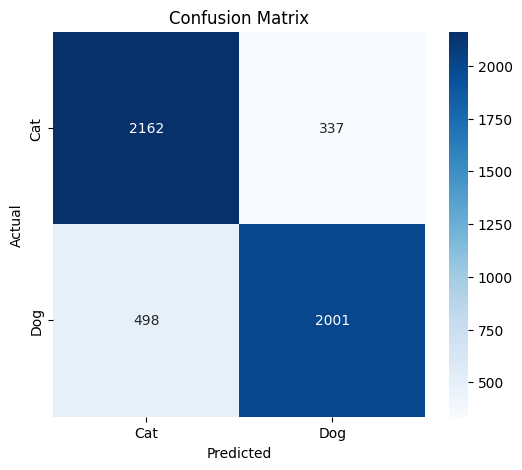

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy & Loss Graphs

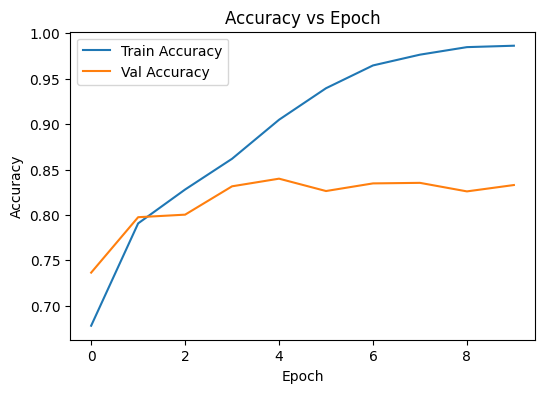

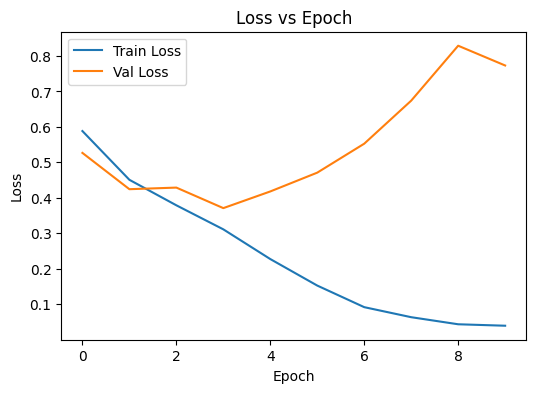

In [14]:
# Accuracy vs Epoch
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss vs Epoch
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Observations

1. **Overfitting is clearly visible**: Training accuracy climbed steadily to 98.7% while validation accuracy plateaued around 83%, and the loss curves confirm this — training loss dropped continuously to near 0.05, while validation loss bottomed out around epoch 3 (~0.37) and then rose sharply to ~0.83 by epoch 8. The model memorized the training data after epoch 3–4 rather than generalizing further.

2. **Test performance is solid but imperfect**: the model achieved a test accuracy of 83.29%, with precision of 85.59%, recall of 80.07%, and an F1-score of 82.74%. The gap between precision and recall shows the model is slightly more conservative about predicting "Dog" — it's more confident when it does predict Dog, but misses a meaningful fraction of actual dogs.

3. **Class-wise error asymmetry**: from the confusion matrix, 337 cats were misclassified as dogs, while 498 dogs were misclassified as cats — nearly 50% more errors in that direction. This means the model finds dog images relatively harder to distinguish, possibly due to greater visual variability (breeds, poses, fur patterns) among dog images compared to cat images.

4. **Early stopping would likely help**: since validation loss was at its best around epoch 3–4 and degraded afterward, training for the full 10 epochs without early stopping or regularization (e.g., dropout, data augmentation) led to unnecessary overfitting in the later epochs.

### Conclusion

This project developed a Convolutional Neural Network (CNN) to classify images of cats and dogs, achieving a test accuracy of **83.29%**, with a precision of 85.59%, recall of 80.07%, and an F1-score of 82.74%. The model learned meaningful visual features quickly, reaching over 80% validation accuracy within the first two epochs, though training beyond epoch 3–4 led to overfitting, as seen in the diverging train/validation loss curves.

Convolution layers are central to this performance because they automatically extract spatial features — edges, textures, and shapes — directly from raw pixel data, removing the need for manual feature engineering. Pooling layers then reduce the spatial dimensions of these feature maps, lowering computational cost and making the learned features more robust to small translations and distortions in the image, such as a cat or dog appearing in a slightly different position or scale.

Compared to a standard Artificial Neural Network (ANN), a CNN's key advantage for image classification is its ability to preserve and exploit spatial relationships between pixels, since ANNs flatten images into 1D vectors and lose this structure, resulting in far more parameters and weaker performance on visual data.

One limitation of CNNs, evident in this project, is their tendency to overfit when trained for too many epochs without regularization — the model achieved near-perfect training accuracy (98.7%) while validation accuracy stagnated around 83%, showing that without techniques like dropout, data augmentation, or early stopping, CNNs can memorize training data rather than generalize well to unseen images.